DATASET INFORMATION
Shape : (21263, 82)

Using ALL Features
Total Features: 81


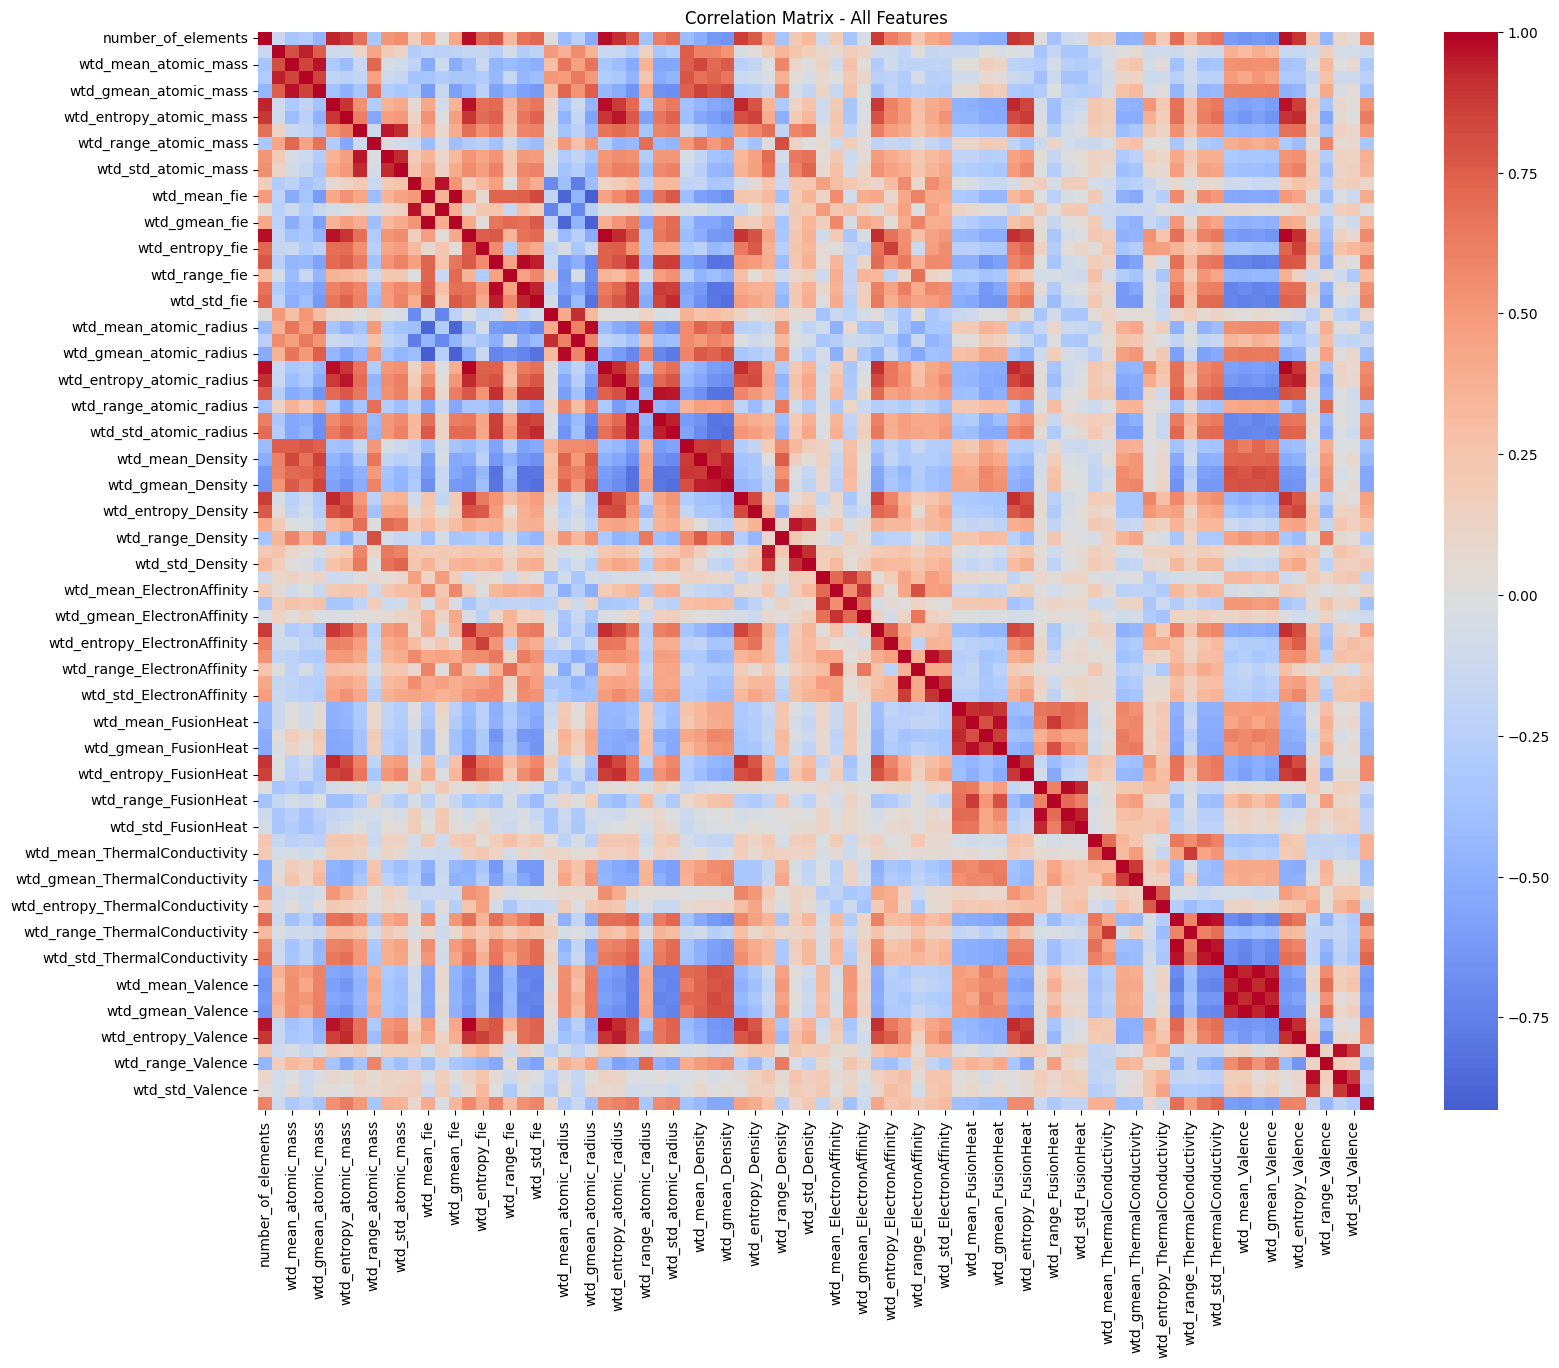



DECISION TREE PERFORMANCE
MAE           : 7.3658
MSE           : 146.1180
RMSE          : 12.0879
R2 Score      : 0.8731
Adjusted R2   : 0.8706
MAPE          : 1.6571


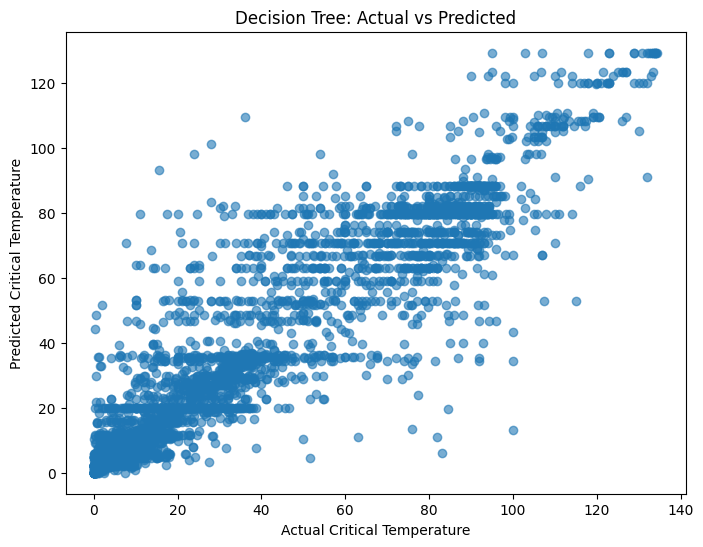

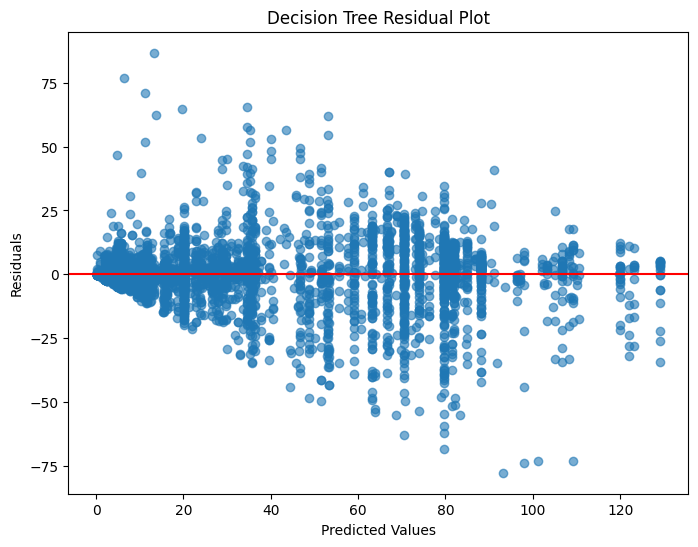



FEATURE IMPORTANCE
                          Feature  Importance
67      range_ThermalConductivity    0.583138
64  wtd_gmean_ThermalConductivity    0.134708
39                    std_Density    0.030155
78              wtd_range_Valence    0.018827
74              wtd_gmean_Valence    0.018613
..                            ...         ...
37                  range_Density    0.000003
13                      gmean_fie    0.000000
0              number_of_elements    0.000000
77                  range_Valence    0.000000
79                    std_Valence    0.000000

[81 rows x 2 columns]

Top 20 Important Features
                            Feature  Importance
67        range_ThermalConductivity    0.583138
64    wtd_gmean_ThermalConductivity    0.134708
39                      std_Density    0.030155
78                wtd_range_Valence    0.018827
74                wtd_gmean_Valence    0.018613
8             wtd_range_atomic_mass    0.017785
27              range_atomic_radius    0.

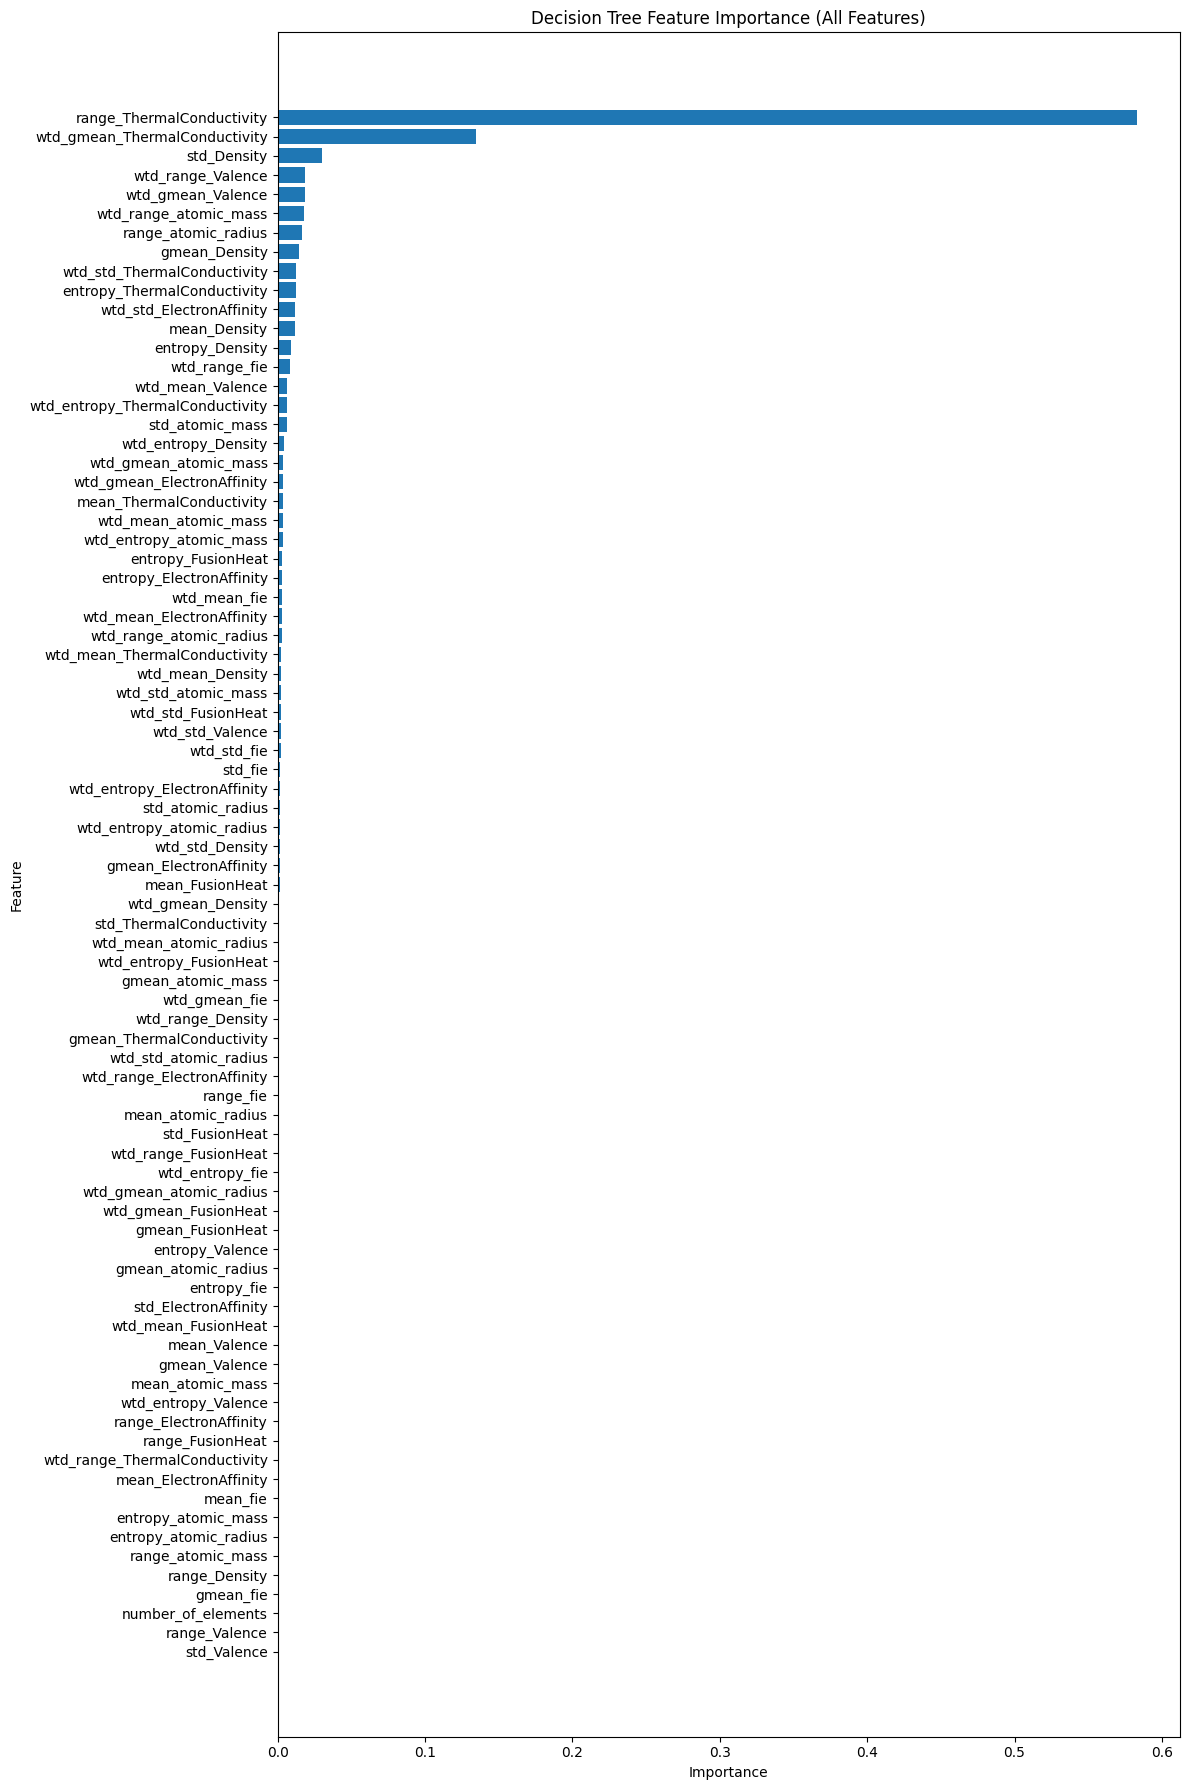

In [2]:
# ============================================================
# SUPERCONDUCTOR CRITICAL TEMPERATURE PREDICTION
# DECISION TREE REGRESSOR USING ALL FEATURES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("train.csv")

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Shape :", df.shape)

# ============================================================
# 2. TARGET VARIABLE
# ============================================================

target = "critical_temp"

# ============================================================
# 3. INPUT AND OUTPUT
# ============================================================

X = df.drop(columns=[target])
y = df[target]

print("\nUsing ALL Features")
print("Total Features:", X.shape[1])

# ============================================================
# 4. HANDLE MISSING VALUES
# ============================================================

X = X.fillna(X.median())
y = y.fillna(y.median())

# ============================================================
# 5. CORRELATION MATRIX OF ALL FEATURES
# ============================================================

corr_matrix = df.corr()

plt.figure(figsize=(18,14))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix - All Features")

plt.show()

# ============================================================
# 6. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ============================================================
# 7. DECISION TREE MODEL
# ============================================================

model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)

# ============================================================
# 8. PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

# ============================================================
# 9. EVALUATION METRICS
# ============================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

mape = mean_absolute_percentage_error(
    y_test,
    y_pred
)

n = len(y_test)
p = X_test.shape[1]

adj_r2 = 1 - (
    ((1-r2)*(n-1))
    /
    (n-p-1)
)

print("\n")
print("=" * 60)
print("DECISION TREE PERFORMANCE")
print("=" * 60)

print(f"MAE           : {mae:.4f}")
print(f"MSE           : {mse:.4f}")
print(f"RMSE          : {rmse:.4f}")
print(f"R2 Score      : {r2:.4f}")
print(f"Adjusted R2   : {adj_r2:.4f}")
print(f"MAPE          : {mape:.4f}")

# ============================================================
# 10. ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Critical Temperature")
plt.ylabel("Predicted Critical Temperature")
plt.title("Decision Tree: Actual vs Predicted")

plt.show()

# ============================================================
# 11. RESIDUAL PLOT
# ============================================================

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Decision Tree Residual Plot")

plt.show()

# ============================================================
# 12. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n")
print("=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

print(importance)

# ============================================================
# 13. TOP 20 IMPORTANT FEATURES
# ============================================================

print("\nTop 20 Important Features")

print(importance.head(20))

# ============================================================
# 14. FEATURE IMPORTANCE GRAPH
# ============================================================

plt.figure(figsize=(12,18))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Decision Tree Feature Importance (All Features)"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()